Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

Loading the datasets

In [3]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

Initial data inspection

In [4]:
print("Training data shape:", train.shape)
print("Test data shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)

print("\nTraining")

print("\nTest data:")
display(test.head())

print("\nTraining data information:")
train.info()

Training data shape: (6818, 13)
Test data shape: (1705, 12)
Sample submission shape: (1705, 2)

Training

Test data:


,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format
0,row_00009,PRD-2WLNC8,8.628,Low Fat,0.0167,household,190.72,STORE-HL7,23,Medium,Tier_3,Superstore
1,row_00015,PRD-LV9PLM,6.993,Low Fat,0.0579,Health and Hygiene,261.07,STORE-9RG,28,Small,Tier_2,Standard Supermarket
2,row_00019,PRD-ET6ZI7,NaN,Low Fat,0.1262,FRUITS AND VEGETABLES,112.50,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket
3,row_00020,PRD-6RX35U,14.034,Regular,0.0761,frozen foods,200.71,STORE-DKU,30,NaN,Tier_2,Standard Supermarket
4,row_00023,PRD-I4J38V,13.063,Low Fat,0.0650,Frozen Foods,150.59,STORE-89Z,33,Medium,Tier_1,Standard Supermarket



Training data information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   6818 non-null   object 
 1   product_code         6818 non-null   object 
 2   product_weight_kg    5593 non-null   float64
 3   fat_content          6818 non-null   object 
 4   shelf_visibility     6818 non-null   float64
 5   product_category     6818 non-null   object 
 6   product_price        6818 non-null   float64
 7   store_code           6818 non-null   object 
 8   store_age_years      6818 non-null   int64  
 9   store_size           4899 non-null   object 
 10  store_location_tier  6818 non-null   object 
 11  store_format         6818 non-null   object 
 12  total_sales          6818 non-null   float64
dtypes: float64(4), int64(1), object(8)
memory usage: 692.6+ KB


In [5]:
# Check for missing values
print("Missing values in training data:")
display(train.isnull().sum())

print("\nMissing values in test data:")
display(test.isnull().sum())


# Check for duplicate rows
print("\nDuplicate rows in training data:", train.duplicated().sum())
print("Duplicate rows in test data:", test.duplicated().sum())


# Check the data types of each column
print("\nTraining data types:")
display(train.dtypes)


# Check the unique values in each column
print("\nNumber of unique values per column:")
display(train.nunique().sort_values())

Missing values in training data:


,0
id,0
product_code,0
product_weight_kg,1225
fat_content,0
shelf_visibility,0
product_category,0
product_price,0
store_code,0
store_age_years,0
store_size,1919



Missing values in test data:


,0
id,0
product_code,0
product_weight_kg,306
fat_content,0
shelf_visibility,0
product_category,0
product_price,0
store_code,0
store_age_years,0
store_size,491



Duplicate rows in training data: 0
Duplicate rows in test data: 0

Training data types:


,0
id,object
product_code,object
product_weight_kg,float64
fat_content,object
shelf_visibility,float64
product_category,object
product_price,float64
store_code,object
store_age_years,int64
store_size,object



Number of unique values per column:


,0
fat_content,2
store_size,3
store_location_tier,3
store_format,4
store_age_years,9
store_code,10
product_category,48
product_code,1555
shelf_visibility,1732
product_weight_kg,4675


Summary statistics for total_sales:


,total_sales
count,6818.000000
mean,2174.756574
std,1697.894956
min,32.700000
25%,834.792500
50%,1790.890000
75%,3092.587500
max,12996.820000



Missing total_sales values: 0


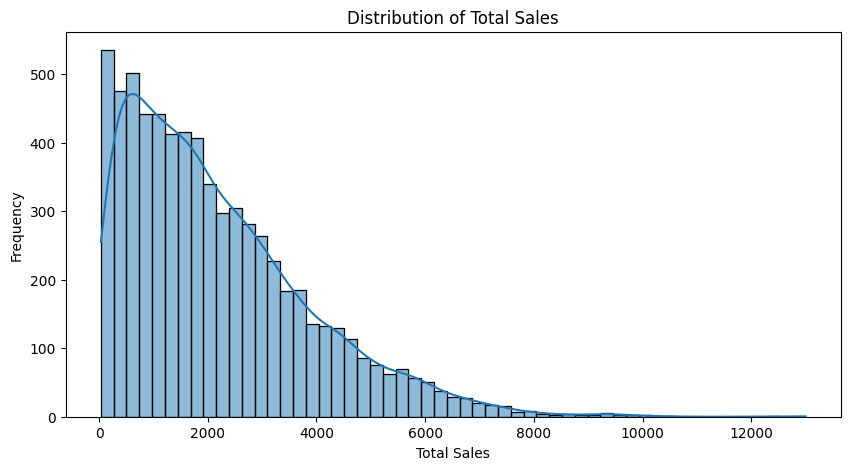

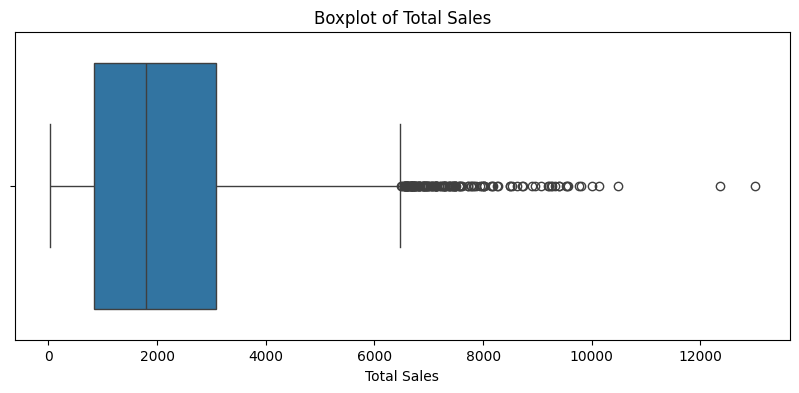

In [6]:

# TARGET VARIABLE ANALYSIS

# Basic statistics of total sales
print("Summary statistics for total_sales:")
display(train["total_sales"].describe())


# Check for missing target values
print("\nMissing total_sales values:", train["total_sales"].isnull().sum())


# Check the distribution of total sales
plt.figure(figsize=(10, 5))
sns.histplot(train["total_sales"], kde=True)
plt.title("Distribution of Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Frequency")
plt.show()


# Check for potential outliers using a boxplot
plt.figure(figsize=(10, 4))
sns.boxplot(x=train["total_sales"])
plt.title("Boxplot of Total Sales")
plt.xlabel("Total Sales")
plt.show()

In [7]:

#  EXPLORATORY DATA ANALYSIS
#  Numerical Features vs Total Sales

# Select numerical columns
numerical_features = train.select_dtypes(include=np.number).columns.tolist()

print("Numerical features:")
print(numerical_features)

Numerical features:
['product_weight_kg', 'shelf_visibility', 'product_price', 'store_age_years', 'total_sales']


In [8]:
# Correlation of numerical variables with total_sales
correlation = train[numerical_features].corr()["total_sales"].sort_values(
    ascending=False
)

print("\nCorrelation with total_sales:")
display(correlation)


Correlation with total_sales:


,total_sales
total_sales,1.000000
product_price,0.569833
store_age_years,0.039443
product_weight_kg,0.015532
shelf_visibility,-0.118124


In [9]:
# Identify categorical features
categorical_features = train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

Categorical features:
['id', 'product_code', 'fat_content', 'product_category', 'store_code', 'store_size', 'store_location_tier', 'store_format']


In [10]:
# Remove the row identifier from the categorical features
categorical_features.remove("id")

print("Categorical features for EDA:")
print(categorical_features)

Categorical features for EDA:
['product_code', 'fat_content', 'product_category', 'store_code', 'store_size', 'store_location_tier', 'store_format']


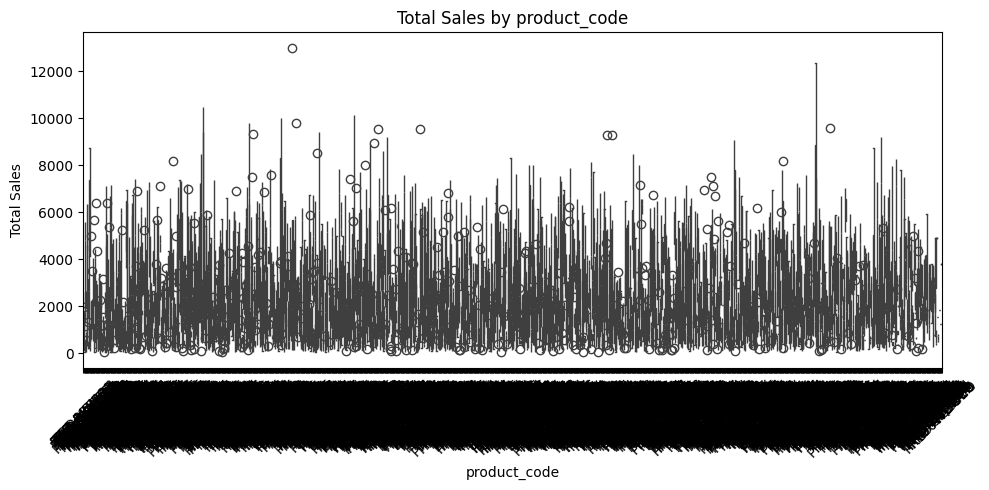

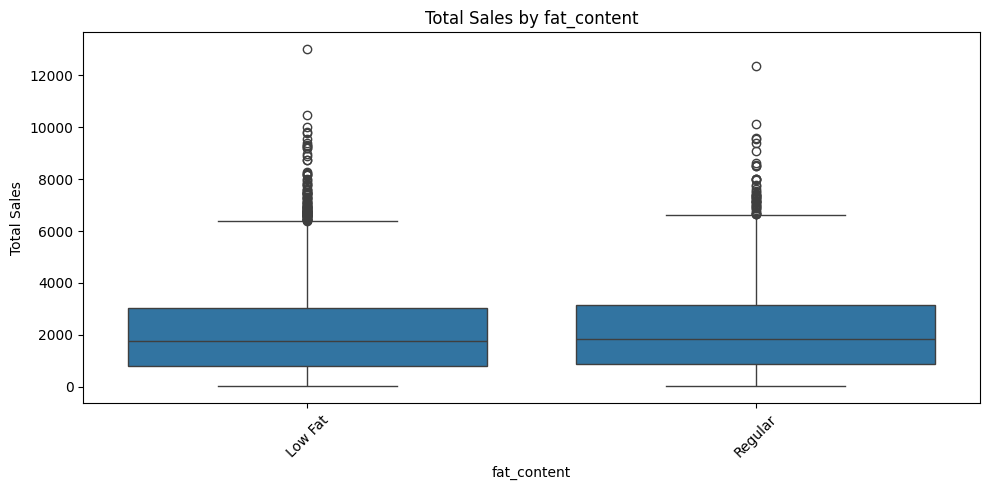

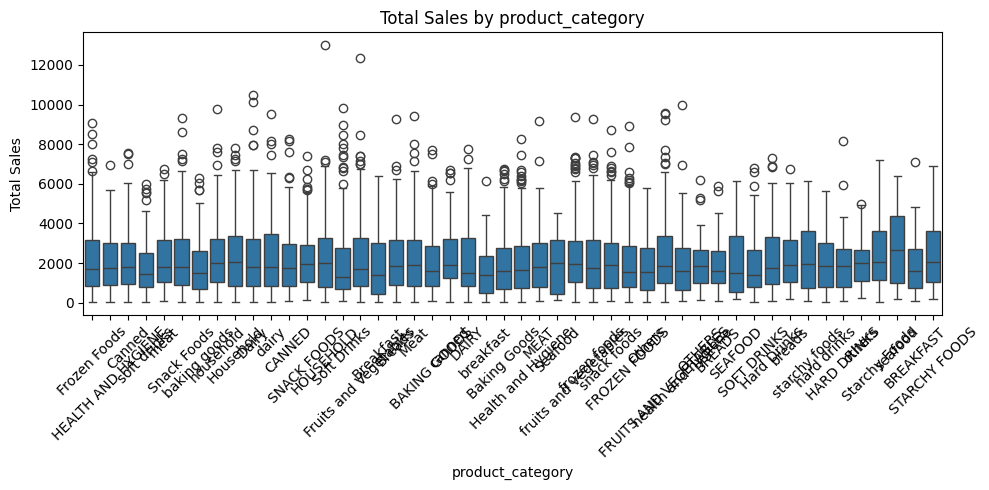

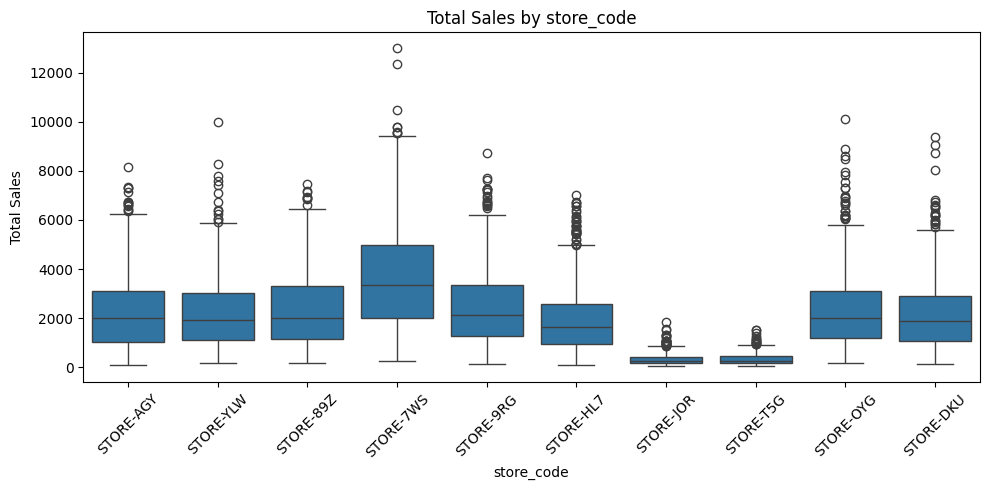

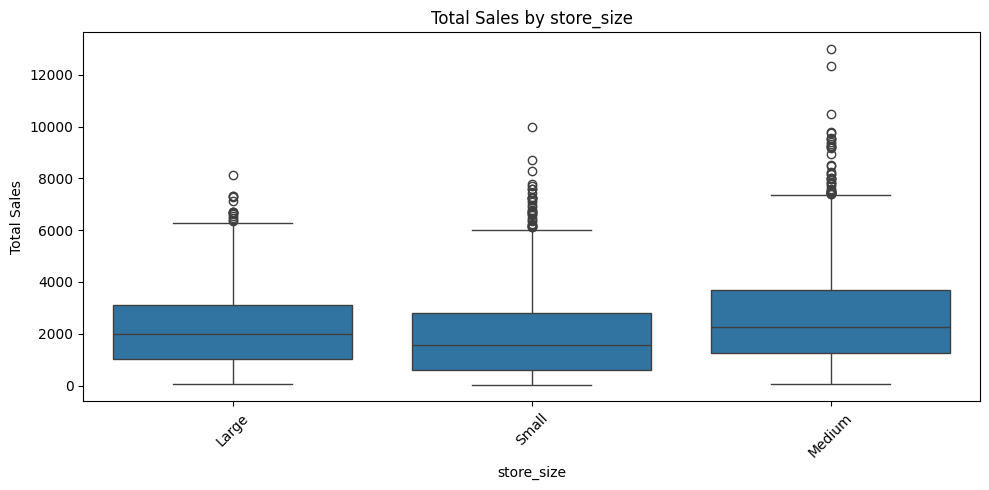

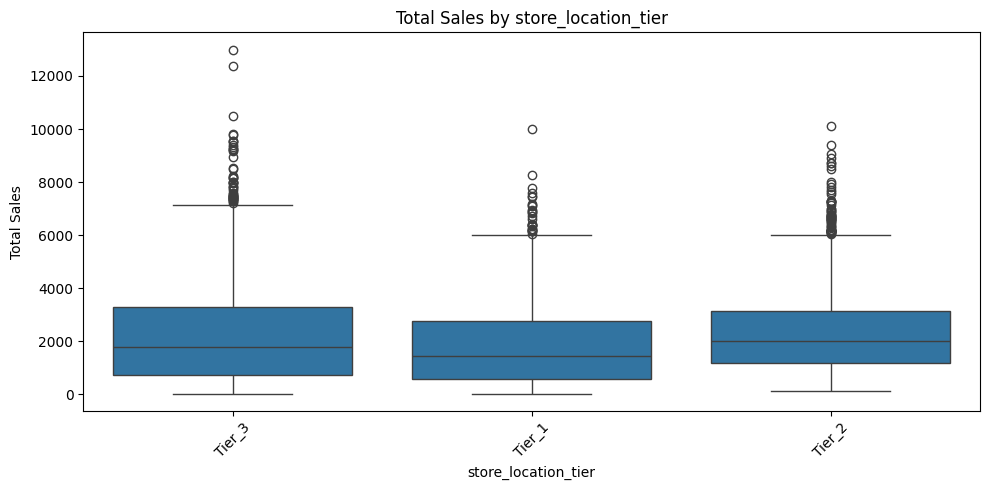

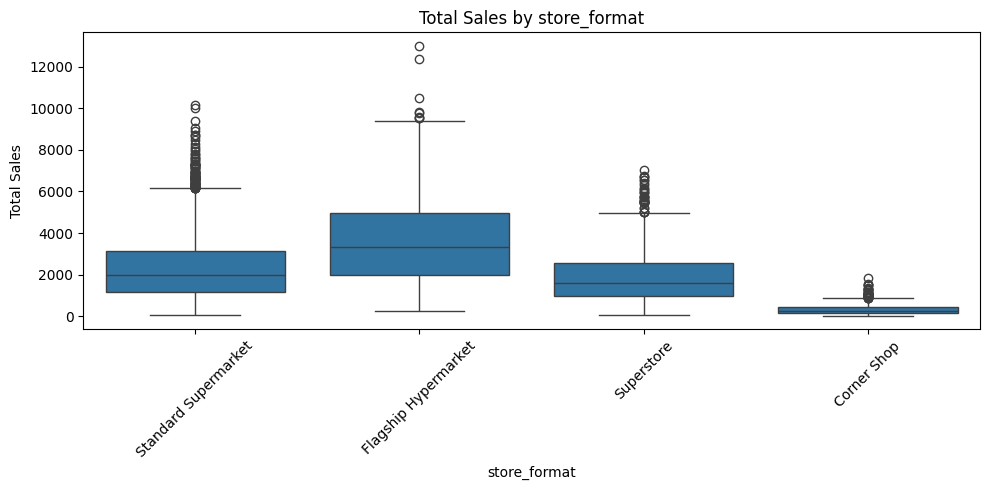

In [11]:

# TOTAL SALES ACROSS CATEGORICAL FEATURES

for feature in categorical_features:
    plt.figure(figsize=(10, 5))

    sns.boxplot(
        data=train,
        x=feature,
        y="total_sales"
    )

    plt.title(f"Total Sales by {feature}")
    plt.xlabel(feature)
    plt.ylabel("Total Sales")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Observations from Categorical Features

The boxplots show that the relationship between categorical variables and total sales varies across the different features.

- `fat_content` shows considerable overlap between Low Fat and Regular products, suggesting relatively similar sales distributions.
- `product_category` shows some variation in sales across categories, although there is substantial overlap between many categories.
- `store_code` shows noticeable differences in sales distributions between stores, indicating that store-specific characteristics may be important for predicting sales.
- `store_size` shows differences in the typical sales levels across store sizes.
- `store_location_tier` also shows variation in sales distributions across the different location tiers.
- `store_format` shows particularly noticeable differences in total sales, with some store formats having substantially higher typical sales than others.

These observations suggest that several categorical features may contain useful predictive information. However, visual differences alone do not determine their predictive importance, so their usefulness will be evaluated further during feature engineering and model development.

## 8. Missing Value Analysis

 examining the missing values in the training and test datasets and determine whether they occur randomly or are associated with particular products or stores.

In [12]:

# MISSING VALUE DISTRIBUTION

missing_summary = pd.DataFrame({
    "Train Missing": train.isnull().sum(),
    "Train Missing (%)": train.isnull().mean() * 100,
    "Test Missing": test.isnull().sum(),
    "Test Missing (%)": test.isnull().mean() * 100
})

missing_summary = missing_summary[
    (missing_summary["Train Missing"] > 0) |
    (missing_summary["Test Missing"] > 0)
]

display(missing_summary)

,Train Missing,Train Missing (%),Test Missing,Test Missing (%)
product_weight_kg,1225,17.967146,306.0,17.947214
store_size,1919,28.146084,491.0,28.797654


### Investigating the Pattern of Missing Values

The missing-value analysis shows that `product_weight_kg` is missing in approximately 18% of the observations, while `store_size` is missing in approximately 28% of the observations.

The proportions are similar in both the training and test datasets.

In [13]:

#INVESTIGATING MISSING STORE SIZE

print("Store size distribution:")
display(train["store_size"].value_counts(dropna=False))

print("\nStore size by store code:")
display(
    pd.crosstab(
        train["store_code"],
        train["store_size"],
        dropna=False
    )
)

Store size distribution:


,count
store_size,
Medium,2218
Small,1933
NaN,1919
Large,748



Store size by store code:


store_size,Large,Medium,Small,NaN
store_code,,,,
STORE-7WS,0,748,0,0
STORE-89Z,0,728,0,0
STORE-9RG,0,0,752,0
STORE-AGY,748,0,0,0
STORE-DKU,0,0,0,736
STORE-HL7,0,742,0,0
STORE-JOR,0,0,0,439
STORE-OYG,0,0,0,744
STORE-T5G,0,0,427,0


### Findings from Store Size Missingness

The distribution of `store_size` shows that approximately 28% of the observations are missing this information.

Further investigation reveals that the missing values are concentrated in specific `store_code` categories. Several stores have their `store_size` completely missing, while other stores have a consistent store size across their observations.

This suggests that the missingness is related to the store rather than occurring randomly.

In [14]:

# INVESTIGATING MISSING PRODUCT WEIGHT

print("Product weight statistics:")
display(train["product_weight_kg"].describe())

print("\nProduct weight missingness by product code:")
display(
    train.groupby("product_code")["product_weight_kg"]
    .agg(["count", "mean"])
    .sort_values("count")
    .head(20)
)

Product weight statistics:


,product_weight_kg
count,5593.000000
mean,12.850876
std,4.646542
min,4.482000
25%,8.750000
50%,12.647000
75%,16.894000
max,21.883000



Product weight missingness by product code:


,count,mean
product_code,,
PRD-8CL0LC,0,NaN
PRD-DQHDK3,0,NaN
PRD-DH3TKZ,0,NaN
PRD-7JH2LK,0,NaN
PRD-QIGCT2,0,NaN
PRD-M80O2R,0,NaN
PRD-MRKSQJ,0,NaN
PRD-NBDVPI,0,NaN
PRD-7SGMSO,1,19.778


In [15]:

# HANDLE MISSING PRODUCT WEIGHT

# Fill using product average weight
product_weight_mean = train.groupby("product_code")[
    "product_weight_kg"
].transform("mean")

train["product_weight_kg"] = train[
    "product_weight_kg"
].fillna(product_weight_mean)

# Fill remaining missing values with overall median
overall_weight_median = train["product_weight_kg"].median()

train["product_weight_kg"] = train[
    "product_weight_kg"
].fillna(overall_weight_median)

In [16]:
train["product_weight_kg"].isnull().sum()

np.int64(0)

### 9.2 Handling Missing Store Size

The missing `store_size` values are concentrated in specific stores. Since each observed store has a consistent store size, we will use the available store-level information to fill missing values where possible.

For stores whose size is completely unavailable,fallback category will be used so that the model can still process those observations without assuming a specific store size.

In [17]:

# Fill missing store size using store-level information


# Find the known store size for each store
store_size_map = (
    train.dropna(subset=["store_size"])
    .drop_duplicates("store_code")
    .set_index("store_code")["store_size"]
)

# Fill missing values using the corresponding store's known size
train["store_size"] = train["store_size"].fillna(
    train["store_code"].map(store_size_map)
)

# Use "Unknown" for stores whose size is completely unavailable
train["store_size"] = train["store_size"].fillna("Unknown")

print("Remaining missing values:", train["store_size"].isnull().sum())

print("\nStore size distribution after imputation:")
display(train["store_size"].value_counts())

Remaining missing values: 0

Store size distribution after imputation:


,count
store_size,
Medium,2218
Small,1933
Unknown,1919
Large,748


### Observation After Imputation

The missing `store_size` values were successfully handled using store-level information where available. For stores with no recorded size in the training data, the missing values were assigned to an `Unknown` category rather than assuming a particular store size.

This preserves the information that the original value was unavailable while allowing the feature to be used by machine learning models.

### Applying Preprocessing to the Test Set

The same preprocessing steps used for the training data must also be applied to the test data.

For `product_weight_kg`, we will use product-level information learned from the training data and use the training median as a fallback. For `store_size`, we will use the store-level mapping learned from the training data and assign `Unknown` when no information is available.

Using the training data to determine these values helps prevent information from the test set from influencing the preprocessing decisions.

In [18]:

# Apply preprocessing to the test set

# Product weight

# Product-level mean learned from training data
test_product_weight_mean = test["product_code"].map(
    train.groupby("product_code")["product_weight_kg"].mean()
)

test["product_weight_kg"] = test["product_weight_kg"].fillna(
    test_product_weight_mean
)

# Training median as fallback
test["product_weight_kg"] = test["product_weight_kg"].fillna(
    overall_weight_median
)


#  Store size

# Use store-size mapping learned from training data
test["store_size"] = test["store_size"].fillna(
    test["store_code"].map(store_size_map)
)

# Unknown when no store size is available
test["store_size"] = test["store_size"].fillna("Unknown")


# Check remaining missing values
print("Missing values in test data:")
display(test.isnull().sum())

Missing values in test data:


,0
id,0
product_code,0
product_weight_kg,0
fat_content,0
shelf_visibility,0
product_category,0
product_price,0
store_code,0
store_age_years,0
store_size,0


In [19]:
print("Missing product weight:",
      test["product_weight_kg"].isnull().sum())

print("Missing store size:",
      test["store_size"].isnull().sum())

Missing product weight: 0
Missing store size: 0


In [20]:

# Final preprocessing check

print("Training data shape:", train.shape)
print("Test data shape:", test.shape)

print("\nRemaining missing values in training data:")
display(train.isnull().sum())

print("\nRemaining missing values in test data:")
display(test.isnull().sum())

print("\nDuplicate rows in training data:", train.duplicated().sum())
print("Duplicate rows in test data:", test.duplicated().sum())

Training data shape: (6818, 13)
Test data shape: (1705, 12)

Remaining missing values in training data:


,0
id,0
product_code,0
product_weight_kg,0
fat_content,0
shelf_visibility,0
product_category,0
product_price,0
store_code,0
store_age_years,0
store_size,0



Remaining missing values in test data:


,0
id,0
product_code,0
product_weight_kg,0
fat_content,0
shelf_visibility,0
product_category,0
product_price,0
store_code,0
store_age_years,0
store_size,0



Duplicate rows in training data: 0
Duplicate rows in test data: 0


### Understanding Product and Store Structure

The dataset contains product and store identifiers that may capture information about individual products and stores.

Before transforming these variables, we will examine how frequently each product and store appears in the dataset. This will help us determine whether these identifiers contain repeated information that can be useful for prediction.

In [21]:

# Product and Store Frequency

product_frequency = train["product_code"].value_counts()

store_frequency = train["store_code"].value_counts()

print("Number of unique products:", train["product_code"].nunique())
print("Number of unique stores:", train["store_code"].nunique())

print("\nProduct frequency:")
display(product_frequency.describe())

print("\nStore frequency:")
display(store_frequency)

Number of unique products: 1555
Number of unique stores: 10

Product frequency:


,count
count,1555.000000
mean,4.384566
std,1.556328
min,1.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,9.000000



Store frequency:


,count
store_code,
STORE-YLW,754
STORE-9RG,752
STORE-AGY,748
STORE-7WS,748
STORE-OYG,744
STORE-HL7,742
STORE-DKU,736
STORE-89Z,728
STORE-JOR,439


### Creating Derived Features
 creating a small number of derived numerical features from the existing variables.

In [22]:

# Create derived numerical features

for df in [train, test]:

    # Price relative to product weight
    df["price_per_kg"] = df["product_price"] / df["product_weight_kg"]

    # Product price adjusted by shelf visibility
    df["price_visibility_interaction"] = (
        df["product_price"] * df["shelf_visibility"]
    )

    # Product weight and shelf visibility interaction
    df["weight_visibility_interaction"] = (
        df["product_weight_kg"] * df["shelf_visibility"]
    )

print("New features created:")
print([
    "price_per_kg",
    "price_visibility_interaction",
    "weight_visibility_interaction"
])

New features created:
['price_per_kg', 'price_visibility_interaction', 'weight_visibility_interaction']


In [23]:

# Check engineered features

engineered_features = [
    "price_per_kg",
    "price_visibility_interaction",
    "weight_visibility_interaction"
]

display(train[engineered_features].describe())

print("\nMissing values:")
display(train[engineered_features].isnull().sum())

print("\nInfinite values:")
display(
    np.isinf(train[engineered_features]).sum()
)

,price_per_kg,price_visibility_interaction,weight_visibility_interaction
count,6818.000000,6818.000000,6818.000000
mean,12.671086,9.217343,0.840521
std,8.006196,8.902052,0.759319
min,1.664982,0.000000,0.000000
25%,6.690595,2.945857,0.296081
50%,10.905983,6.342222,0.613871
75%,16.356417,13.129652,1.165768
max,52.648482,80.377720,6.296367



Missing values:


,0
price_per_kg,0
price_visibility_interaction,0
weight_visibility_interaction,0



Infinite values:


,0
price_per_kg,0
price_visibility_interaction,0
weight_visibility_interaction,0


### Observation

The engineered features contain no missing or infinite values. Their summary statistics also show reasonable ranges, so they can be included in the modelling dataset.

These features will be evaluated alongside the original variables to determine whether they improve predictive performance.

In [24]:

# Check product-store structure

product_store_counts = train.groupby("product_code")["store_code"].nunique()

print("Products appearing in multiple stores:",
      (product_store_counts > 1).sum())

print("Products appearing in only one store:",
      (product_store_counts == 1).sum())

print("\nNumber of stores per product:")
display(product_store_counts.value_counts().sort_index())

Products appearing in multiple stores: 1509
Products appearing in only one store: 46

Number of stores per product:


,count
store_code,
1,46
2,140
3,251
4,394
5,351
6,240
7,97
8,35
9,1


In [25]:

# Check for repeated product-store combinations

product_store_counts = (
    train.groupby(["product_code", "store_code"])
    .size()
)

print("Total rows:", len(train))
print("Unique product-store combinations:", product_store_counts.nunique())

print(
    "Repeated product-store combinations:",
    (product_store_counts > 1).sum()
)

print("\nFrequency of product-store combinations:")
display(product_store_counts.value_counts().sort_index())

Total rows: 6818
Unique product-store combinations: 1
Repeated product-store combinations: 0

Frequency of product-store combinations:


,count
1,6818


In [26]:

# Create training and validation sets

from sklearn.model_selection import train_test_split

# Separate features and target
X = train.drop(columns=["total_sales", "id"])
y = train["total_sales"]

# 80% training, 20% validation
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Validation set shape:", X_valid.shape)

Training set shape: (5454, 14)
Validation set shape: (1364, 14)


In [27]:

# Identify numerical and categorical features

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X_train.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['product_code', 'fat_content', 'product_category', 'store_code', 'store_size', 'store_location_tier', 'store_format']

Numerical features:
['product_weight_kg', 'shelf_visibility', 'product_price', 'store_age_years', 'price_per_kg', 'price_visibility_interaction', 'weight_visibility_interaction']


In [28]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.9 MB/s eta 0:00:00


In [29]:
from catboost import CatBoostRegressor

print("CatBoost imported successfully!")

CatBoost imported successfully!


In [30]:

# First CatBoost Model

from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Create the model
model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

# Train the model
model.fit(
    X_train,
    y_train,
    cat_features=categorical_features,
    eval_set=(X_valid, y_valid),
    early_stopping_rounds=50
)

0:	learn: 1648.3945804	test: 1671.7680033	best: 1671.7680033 (0)	total: 77.3ms	remaining: 38.5s
100:	learn: 1054.6969728	test: 1069.2094564	best: 1069.2094564 (100)	total: 2.03s	remaining: 8.03s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1067.030898
bestIteration = 129

Shrink model to first 130 iterations.


CatBoostRegressor(depth=6, iterations=500, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=100)

In [31]:

# Evaluate the first model

y_valid_pred = model.predict(X_valid)

rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))

print(f"Validation RMSE: {rmse:.2f}")

Validation RMSE: 1067.03


In [32]:
# Compare actual vs predicted sales

results = pd.DataFrame({
    "Actual": y_valid.values,
    "Predicted": y_valid_pred
})

results["Error"] = results["Actual"] - results["Predicted"]
results["Absolute_Error"] = results["Error"].abs()

display(results.describe())

,Actual,Predicted,Error,Absolute_Error
count,1364.000000,1364.000000,1364.000000,1364.000000
mean,2221.085660,2185.532624,35.553035,762.036429
std,1716.518516,1290.569582,1066.829568,747.171137
min,37.870000,17.444850,-3921.873704,0.056936
25%,851.572500,1110.821224,-504.117407,201.013065
50%,1839.350000,2178.806523,-27.305226,518.655203
75%,3154.897500,3127.493675,546.118574,1102.543936
max,9803.380000,6090.575562,5074.348642,5074.348642


In [33]:
# Feature importance

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

display(feature_importance)

,Feature,Importance
5,product_price,53.957465
10,store_format,18.652747
6,store_code,13.697935
7,store_age_years,3.643569
11,price_per_kg,2.325959
8,store_size,1.836026
4,product_category,1.315517
9,store_location_tier,1.227914
0,product_code,0.980748
12,price_visibility_interaction,0.798664


In [34]:
# Simple mean baseline

baseline_prediction = np.full(
    len(y_valid),
    y_train.mean()
)

baseline_rmse = np.sqrt(
    mean_squared_error(y_valid, baseline_prediction)
)

print(f"Baseline RMSE: {baseline_rmse:.2f}")
print(f"CatBoost RMSE: {rmse:.2f}")

Baseline RMSE: 1716.87
CatBoost RMSE: 1067.03


In [35]:
# Original features only

original_features = [
    "product_weight_kg",
    "fat_content",
    "product_category",
    "shelf_visibility",
    "product_price",
    "store_code",
    "store_age_years",
    "store_size",
    "store_location_tier",
    "store_format",
    "product_code"
]

X_train_original = X_train[original_features]
X_valid_original = X_valid[original_features]

model_original = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

model_original.fit(
    X_train_original,
    y_train,
    cat_features=[col for col in categorical_features if col in original_features],
    eval_set=(X_valid_original, y_valid),
    early_stopping_rounds=50
)

y_valid_pred_original = model_original.predict(X_valid_original)

rmse_original = np.sqrt(
    mean_squared_error(y_valid, y_valid_pred_original)
)

print(f"Original features RMSE: {rmse_original:.2f}")
print(f"All features RMSE: {rmse:.2f}")

0:	learn: 1648.0988044	test: 1671.8615060	best: 1671.8615060 (0)	total: 39ms	remaining: 19.4s
100:	learn: 1058.5484292	test: 1067.0379782	best: 1067.0379782 (100)	total: 2.32s	remaining: 9.16s
200:	learn: 1031.5416561	test: 1065.6145630	best: 1064.6542626 (194)	total: 4.35s	remaining: 6.47s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1064.654263
bestIteration = 194

Shrink model to first 195 iterations.
Original features RMSE: 1064.65
All features RMSE: 1067.03


In [36]:
model_depth4 = CatBoostRegressor(
    iterations=700,
    learning_rate=0.05,
    depth=4,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

model_depth4.fit(
    X_train_original,
    y_train,
    cat_features=categorical_features,
    eval_set=(X_valid_original, y_valid),
    early_stopping_rounds=70
)

pred_depth4 = model_depth4.predict(X_valid_original)

rmse_depth4 = np.sqrt(
    mean_squared_error(y_valid, pred_depth4)
)

print(f"Depth 4 RMSE: {rmse_depth4:.2f}")


0:	learn: 1648.0893145	test: 1671.8779799	best: 1671.8779799 (0)	total: 11.7ms	remaining: 8.19s
100:	learn: 1069.1224823	test: 1068.0993427	best: 1068.0685040 (99)	total: 1.3s	remaining: 7.71s
200:	learn: 1056.0014321	test: 1065.7656160	best: 1065.3833860 (176)	total: 2.46s	remaining: 6.12s
Stopped by overfitting detector  (70 iterations wait)

bestTest = 1065.383386
bestIteration = 176

Shrink model to first 177 iterations.
Depth 4 RMSE: 1065.38


In [37]:
# Test CatBoost with deeper trees

model_depth8 = CatBoostRegressor(
    iterations=700,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

model_depth8.fit(
    X_train_original,
    y_train,
    cat_features=categorical_features,
    eval_set=(X_valid_original, y_valid),
    early_stopping_rounds=70
)

pred_depth8 = model_depth8.predict(X_valid_original)

rmse_depth8 = np.sqrt(
    mean_squared_error(y_valid, pred_depth8)
)

print(f"Depth 8 RMSE: {rmse_depth8:.2f}")

0:	learn: 1648.0988044	test: 1671.8615060	best: 1671.8615060 (0)	total: 25.8ms	remaining: 18s
100:	learn: 1036.1927796	test: 1068.0489273	best: 1068.0489273 (100)	total: 5.26s	remaining: 31.2s
200:	learn: 980.5589953	test: 1071.6329912	best: 1067.0294681 (132)	total: 9.81s	remaining: 24.4s
Stopped by overfitting detector  (70 iterations wait)

bestTest = 1067.029468
bestIteration = 132

Shrink model to first 133 iterations.
Depth 8 RMSE: 1067.03


In [38]:
# Test CatBoost with a lower learning rate

model_lr03 = CatBoostRegressor(
    iterations=1200,
    learning_rate=0.03,
    depth=6,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

model_lr03.fit(
    X_train_original,
    y_train,
    cat_features=categorical_features,
    eval_set=(X_valid_original, y_valid),
    early_stopping_rounds=100
)

pred_lr03 = model_lr03.predict(X_valid_original)

rmse_lr03 = np.sqrt(
    mean_squared_error(y_valid, pred_lr03)
)

print(f"Learning Rate 0.03 RMSE: {rmse_lr03:.2f}")

0:	learn: 1665.9342164	test: 1689.7359678	best: 1689.7359678 (0)	total: 29.7ms	remaining: 35.7s
100:	learn: 1074.3598812	test: 1077.6240192	best: 1077.6240192 (100)	total: 2.25s	remaining: 24.5s
200:	learn: 1050.3750197	test: 1066.1644722	best: 1066.1519739 (191)	total: 4.5s	remaining: 22.4s
300:	learn: 1035.3625142	test: 1065.0191434	best: 1065.0036833 (295)	total: 6.06s	remaining: 18.1s
400:	learn: 1020.8820346	test: 1066.5294535	best: 1064.8717179 (306)	total: 7.28s	remaining: 14.5s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 1064.871718
bestIteration = 306

Shrink model to first 307 iterations.
Learning Rate 0.03 RMSE: 1064.87


In [39]:
# Test CatBoost with stronger L2 regularization

model_l2 = CatBoostRegressor(
    iterations=700,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=5,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

model_l2.fit(
    X_train_original,
    y_train,
    cat_features=categorical_features,
    eval_set=(X_valid_original, y_valid),
    early_stopping_rounds=70
)

pred_l2 = model_l2.predict(X_valid_original)

rmse_l2 = np.sqrt(
    mean_squared_error(y_valid, pred_l2)
)

print(f"L2 Regularization RMSE: {rmse_l2:.2f}")

0:	learn: 1648.3588013	test: 1672.1149597	best: 1672.1149597 (0)	total: 11.5ms	remaining: 8.02s
100:	learn: 1058.7377184	test: 1067.3441151	best: 1067.3435103 (99)	total: 1.02s	remaining: 6.06s
200:	learn: 1036.8136523	test: 1065.5331612	best: 1065.2672693 (148)	total: 1.88s	remaining: 4.66s
Stopped by overfitting detector  (70 iterations wait)

bestTest = 1065.267269
bestIteration = 148

Shrink model to first 149 iterations.
L2 Regularization RMSE: 1065.27


In [40]:
# Test CatBoost with a log-transformed target

y_train_log = np.log1p(y_train)

model_log = CatBoostRegressor(
    iterations=700,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

model_log.fit(
    X_train_original,
    y_train_log,
    cat_features=categorical_features,
    eval_set=(X_valid_original, np.log1p(y_valid)),
    early_stopping_rounds=70
)

pred_log = model_log.predict(X_valid_original)

# Convert predictions back to the original sales scale
pred_log_original = np.expm1(pred_log)

rmse_log = np.sqrt(
    mean_squared_error(y_valid, pred_log_original)
)

print(f"Log-transformed target RMSE: {rmse_log:.2f}")

0:	learn: 0.9850699	test: 0.9953379	best: 0.9953379 (0)	total: 6.85ms	remaining: 4.79s
100:	learn: 0.5131143	test: 0.5128254	best: 0.5128179 (99)	total: 955ms	remaining: 5.67s
Stopped by overfitting detector  (70 iterations wait)

bestTest = 0.5125289966
bestIteration = 120

Shrink model to first 121 iterations.
Log-transformed target RMSE: 1116.76


In [41]:
# Test CatBoost with a slightly higher learning rate

model_lr08 = CatBoostRegressor(
    iterations=700,
    learning_rate=0.08,
    depth=6,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

model_lr08.fit(
    X_train_original,
    y_train,
    cat_features=categorical_features,
    eval_set=(X_valid_original, y_valid),
    early_stopping_rounds=70
)

pred_lr08 = model_lr08.predict(X_valid_original)

rmse_lr08 = np.sqrt(
    mean_squared_error(y_valid, pred_lr08)
)

print(f"Learning Rate 0.08 RMSE: {rmse_lr08:.2f}")

0:	learn: 1621.6831961	test: 1645.3822985	best: 1645.3822985 (0)	total: 10.3ms	remaining: 7.21s
100:	learn: 1041.8544178	test: 1068.0121888	best: 1067.1378565 (83)	total: 990ms	remaining: 5.87s
Stopped by overfitting detector  (70 iterations wait)

bestTest = 1067.137856
bestIteration = 83

Shrink model to first 84 iterations.
Learning Rate 0.08 RMSE: 1067.14


In [42]:
# Create a store-category interaction feature

for df in [train, test]:
    df["store_category"] = (
        df["store_code"] + "_" + df["product_category"]
    )

print("Unique store-category combinations:",
      train["store_category"].nunique())

Unique store-category combinations: 474


In [43]:
# Add the new interaction feature to the training and validation sets

X_train_interaction = X_train.copy()
X_valid_interaction = X_valid.copy()

X_train_interaction["store_category"] = train.loc[
    X_train_interaction.index, "store_category"
]

X_valid_interaction["store_category"] = train.loc[
    X_valid_interaction.index, "store_category"
]

features_with_interaction = original_features + ["store_category"]

categorical_features_interaction = [
    col for col in features_with_interaction
    if X_train_interaction[col].dtype == "object"
]

print("Number of features:", len(features_with_interaction))
print("Categorical features:", categorical_features_interaction)

Number of features: 12
Categorical features: ['fat_content', 'product_category', 'store_code', 'store_size', 'store_location_tier', 'store_format', 'product_code', 'store_category']


In [44]:
# Train CatBoost with the store-category interaction feature

model_interaction = CatBoostRegressor(
    iterations=700,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

model_interaction.fit(
    X_train_interaction[features_with_interaction],
    y_train,
    cat_features=categorical_features_interaction,
    eval_set=(X_valid_interaction[features_with_interaction], y_valid),
    early_stopping_rounds=70
)

pred_interaction = model_interaction.predict(
    X_valid_interaction[features_with_interaction]
)

rmse_interaction = np.sqrt(
    mean_squared_error(y_valid, pred_interaction)
)

print(f"Store-category interaction RMSE: {rmse_interaction:.2f}")

0:	learn: 1648.9474465	test: 1672.3899692	best: 1672.3899692 (0)	total: 9.66ms	remaining: 6.75s
100:	learn: 1057.9401010	test: 1067.3440934	best: 1067.3440934 (100)	total: 1.09s	remaining: 6.46s
200:	learn: 1031.3706606	test: 1067.6294990	best: 1065.1155276 (149)	total: 2.15s	remaining: 5.34s
Stopped by overfitting detector  (70 iterations wait)

bestTest = 1065.115528
bestIteration = 149

Shrink model to first 150 iterations.
Store-category interaction RMSE: 1065.12


In [45]:
# Prepare data for Random Forest

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

X_train_encoded = preprocessor.fit_transform(X_train_original)
X_valid_encoded = preprocessor.transform(X_valid_original)

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded validation shape:", X_valid_encoded.shape)

Encoded training shape: (5454, 1617)
Encoded validation shape: (1364, 1617)


In [46]:
# Train Random Forest regression model

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_encoded,
    y_train
)

rf_pred = rf_model.predict(X_valid_encoded)

rf_rmse = np.sqrt(
    mean_squared_error(y_valid, rf_pred)
)

print(f"Random Forest RMSE: {rf_rmse:.2f}")

Random Forest RMSE: 1116.58


In [47]:
# Check whether products and stores in the test set also appear in training

train_products = set(train["product_code"])
test_products = set(test["product_code"])

train_stores = set(train["store_code"])
test_stores = set(test["store_code"])

print("Test products also in train:",
      len(test_products.intersection(train_products)),
      "out of", len(test_products))

print("Test stores also in train:",
      len(test_stores.intersection(train_stores)),
      "out of", len(test_stores))

Test products also in train: 1078 out of 1082
Test stores also in train: 10 out of 10


In [48]:
# Check the best iteration from our current best CatBoost model

print("Best iteration:", model_original.get_best_iteration())
print("Best validation RMSE:", model_original.get_best_score()["validation"]["RMSE"])

Best iteration: 194
Best validation RMSE: 1064.6542626499552


In [49]:
# Train the final CatBoost model on the complete training dataset

final_features = original_features

X_full = train[final_features]
y_full = train["total_sales"]

X_test_final = test[final_features]

final_model = CatBoostRegressor(
    iterations=195,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    random_seed=42,
    verbose=50
)

final_model.fit(
    X_full,
    y_full,
    cat_features=categorical_features
)

print("Final model training completed.")

0:	learn: 1651.8913780	total: 6.03ms	remaining: 1.17s
50:	learn: 1080.9675710	total: 213ms	remaining: 602ms
100:	learn: 1058.2805797	total: 411ms	remaining: 382ms
150:	learn: 1044.1763495	total: 610ms	remaining: 178ms
194:	learn: 1032.8599365	total: 814ms	remaining: 0us
Final model training completed.


## 12. Final Model and Predictions

The best-performing model from the experiments was CatBoost using the original features, with a depth of 6, learning rate of 0.05, and 195 iterations.


In [50]:
# Generate predictions for the competition test data

test_predictions = final_model.predict(X_test_final)

print("Number of predictions:", len(test_predictions))
print("Minimum prediction:", test_predictions.min())
print("Maximum prediction:", test_predictions.max())
print("Mean prediction:", test_predictions.mean())

Number of predictions: 1705
Minimum prediction: 27.16488542298339
Maximum prediction: 6673.029528468454
Mean prediction: 2208.316312112975



The final model has generated predictions for all observations in the test dataset.


In [51]:
# Creating the Kaggle submission file

submission = sample_submission.copy()

submission["total_sales"] = test_predictions

print("Submission shape:", submission.shape)
display(submission.head())

Submission shape: (1705, 2)


,id,total_sales
0,row_00009,2706.994790
1,row_00015,4321.676402
2,row_00019,2999.764163
3,row_00020,3338.980123
4,row_00023,2569.945806


In [52]:
# Verification

print("Missing values:")
print(submission.isnull().sum())

print("\nDuplicate IDs:", submission["id"].duplicated().sum())

print("Submission rows:", len(submission))
print("Test rows:", len(test))

Missing values:
id             0
total_sales    0
dtype: int64

Duplicate IDs: 0
Submission rows: 1705
Test rows: 1705


In [53]:
submission.to_csv("submission.csv", index=False)

print("submission.csv saved successfully.")

submission.csv saved successfully.


Further Model Optimization

The initial CatBoost model produced a Kaggle RMSE of 1079.28.

more experimenting with the model configuration to determine whether generalization can be improved and achieve a better RMSE.


In [54]:
# Experiment 1: Test CatBoost random strength

model_rs = CatBoostRegressor(
    iterations=600,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    random_strength=0.5,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

model_rs.fit(
    X_train_original,
    y_train,
    cat_features=[
        col for col in categorical_features
        if col in original_features
    ],
    eval_set=(X_valid_original, y_valid),
    early_stopping_rounds=60
)

y_valid_pred_rs = model_rs.predict(X_valid_original)

rmse_rs = np.sqrt(
    mean_squared_error(y_valid, y_valid_pred_rs)
)

print(f"Random Strength 0.5 RMSE: {rmse_rs:.4f}")

0:	learn: 1646.0069234	test: 1669.5934759	best: 1669.5934759 (0)	total: 10.4ms	remaining: 6.22s
100:	learn: 1050.9794367	test: 1068.1134246	best: 1068.1134246 (100)	total: 1.01s	remaining: 4.97s
200:	learn: 1022.9744151	test: 1065.0605196	best: 1065.0325018 (198)	total: 1.94s	remaining: 3.85s
Stopped by overfitting detector  (60 iterations wait)

bestTest = 1065.032502
bestIteration = 198

Shrink model to first 199 iterations.
Random Strength 0.5 RMSE: 1065.0325


In [55]:
# Experiment 2: Test Bayesian bootstrap sampling

model_bagging = CatBoostRegressor(
    iterations=600,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    bagging_temperature=1,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

model_bagging.fit(
    X_train_original,
    y_train,
    cat_features=[
        col for col in categorical_features
        if col in original_features
    ],
    eval_set=(X_valid_original, y_valid),
    early_stopping_rounds=60
)

y_valid_pred_bagging = model_bagging.predict(X_valid_original)

rmse_bagging = np.sqrt(
    mean_squared_error(y_valid, y_valid_pred_bagging)
)

print(f"Bagging Temperature 1 RMSE: {rmse_bagging:.4f}")

0:	learn: 1648.0988044	test: 1671.8615060	best: 1671.8615060 (0)	total: 19.7ms	remaining: 11.8s
100:	learn: 1058.5484292	test: 1067.0379782	best: 1067.0379782 (100)	total: 1.58s	remaining: 7.8s
200:	learn: 1031.5416561	test: 1065.6145630	best: 1064.6542626 (194)	total: 3.1s	remaining: 6.15s
Stopped by overfitting detector  (60 iterations wait)

bestTest = 1064.654263
bestIteration = 194

Shrink model to first 195 iterations.
Bagging Temperature 1 RMSE: 1064.6543


##  Alternative Gradient Boosting Model

CatBoost has provided the strongest validation result so far. To determine whether a different tree-based boosting approach can generalize better, we will compare it with another gradient boosting model.

The same validation set and RMSE metric will be used so that the comparison remains fair.

In [56]:
from lightgbm import LGBMRegressor

In [57]:
# Experiment 3: Prepare data for LightGBM

X_train_lgb = X_train_original.copy()
X_valid_lgb = X_valid_original.copy()

# Convert categorical columns to pandas category dtype
for col in categorical_features:
    if col in X_train_lgb.columns:
        X_train_lgb[col] = X_train_lgb[col].astype("category")
        X_valid_lgb[col] = X_valid_lgb[col].astype("category")

print("Training shape:", X_train_lgb.shape)
print("Validation shape:", X_valid_lgb.shape)

Training shape: (5454, 11)
Validation shape: (1364, 11)


In [58]:
# Experiment 3: Train the LightGBM baseline model

lgb_model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0,
    reg_lambda=0,
    random_state=42,
    n_jobs=-1
)

lgb_model.fit(
    X_train_lgb,
    y_train,
    eval_set=[(X_valid_lgb, y_valid)],
    callbacks=[]
)

y_valid_pred_lgb = lgb_model.predict(X_valid_lgb)

rmse_lgb = np.sqrt(
    mean_squared_error(y_valid, y_valid_pred_lgb)
)

print(f"LightGBM Validation RMSE: {rmse_lgb:.4f}")

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000493 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1993
[LightGBM] [Info] Number of data points in the train set: 5454, number of used features: 11
[LightGBM] [Info] Start training from score 2163.170056
LightGBM Validation RMSE: 1145.8911


In [59]:
# Experiment 4: Test a simple CatBoost + LightGBM blend

blend_weights = [0.8, 0.9, 0.95]

for cat_weight in blend_weights:
    lgb_weight = 1 - cat_weight

    blended_pred = (
        cat_weight * y_valid_pred_original
        + lgb_weight * y_valid_pred_lgb
    )

    blend_rmse = np.sqrt(
        mean_squared_error(y_valid, blended_pred)
    )

    print(
        f"CatBoost {cat_weight:.0%} + "
        f"LightGBM {lgb_weight:.0%}: "
        f"{blend_rmse:.4f}"
    )

CatBoost 80% + LightGBM 20%: 1068.6960
CatBoost 90% + LightGBM 10%: 1065.8772
CatBoost 95% + LightGBM 5%: 1065.0657


## Frequency-Based Feature Engineering

The previous experiments showed that store and product-related variables are among the most important predictors.

testing whether the frequency with which a product or store appears in the training data provides additional information.

In [60]:
# Experiment 5: Create frequency-based features

X_train_freq = X_train_original.copy()
X_valid_freq = X_valid_original.copy()

# Calculate frequencies using the training split only
product_freq = X_train_freq["product_code"].value_counts()
store_freq = X_train_freq["store_code"].value_counts()

# Add frequency features
X_train_freq["product_frequency"] = (
    X_train_freq["product_code"].map(product_freq)
)

X_train_freq["store_frequency"] = (
    X_train_freq["store_code"].map(store_freq)
)

X_valid_freq["product_frequency"] = (
    X_valid_freq["product_code"].map(product_freq).fillna(0)
)

X_valid_freq["store_frequency"] = (
    X_valid_freq["store_code"].map(store_freq).fillna(0)
)

print("Training shape:", X_train_freq.shape)
print("Validation shape:", X_valid_freq.shape)

Training shape: (5454, 13)
Validation shape: (1364, 13)


In [61]:
# Experiment 5: Train CatBoost with frequency features

categorical_features_freq = [
    col for col in X_train_freq.select_dtypes(include=["object"]).columns
]

model_freq = CatBoostRegressor(
    iterations=600,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

model_freq.fit(
    X_train_freq,
    y_train,
    cat_features=categorical_features_freq,
    eval_set=(X_valid_freq, y_valid),
    early_stopping_rounds=60
)

y_valid_pred_freq = model_freq.predict(X_valid_freq)

rmse_freq = np.sqrt(
    mean_squared_error(y_valid, y_valid_pred_freq)
)

print(f"Frequency Features RMSE: {rmse_freq:.4f}")

0:	learn: 1651.8128926	test: 1676.1762959	best: 1676.1762959 (0)	total: 10.2ms	remaining: 6.11s
100:	learn: 1057.3190072	test: 1067.4889064	best: 1067.4889064 (100)	total: 1.02s	remaining: 5.03s
200:	learn: 1027.8151057	test: 1066.0742323	best: 1065.2500016 (171)	total: 1.96s	remaining: 3.88s
Stopped by overfitting detector  (60 iterations wait)

bestTest = 1065.250002
bestIteration = 171

Shrink model to first 172 iterations.
Frequency Features RMSE: 1065.2500


In [62]:
# Experiment 6: Test lower L2 regularization

model_l2_low = CatBoostRegressor(
    iterations=700,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=1,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

model_l2_low.fit(
    X_train_original,
    y_train,
    cat_features=categorical_features,
    eval_set=(X_valid_original, y_valid),
    early_stopping_rounds=70
)

y_valid_pred_l2_low = model_l2_low.predict(X_valid_original)

rmse_l2_low = np.sqrt(
    mean_squared_error(y_valid, y_valid_pred_l2_low)
)

print(f"L2 = 1 RMSE: {rmse_l2_low:.4f}")

0:	learn: 1647.8277754	test: 1671.6040079	best: 1671.6040079 (0)	total: 10.2ms	remaining: 7.13s
100:	learn: 1053.7593478	test: 1068.6956627	best: 1068.6956627 (100)	total: 979ms	remaining: 5.81s
200:	learn: 1018.1279766	test: 1067.9458737	best: 1066.0977958 (157)	total: 1.87s	remaining: 4.65s
Stopped by overfitting detector  (70 iterations wait)

bestTest = 1066.097796
bestIteration = 157

Shrink model to first 158 iterations.
L2 = 1 RMSE: 1066.0978


In [63]:
# Experiment 7: Test stronger L2 regularization

model_l2_high = CatBoostRegressor(
    iterations=700,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=5,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

model_l2_high.fit(
    X_train_original,
    y_train,
    cat_features=categorical_features,
    eval_set=(X_valid_original, y_valid),
    early_stopping_rounds=70
)

y_valid_pred_l2_high = model_l2_high.predict(X_valid_original)

rmse_l2_high = np.sqrt(
    mean_squared_error(y_valid, y_valid_pred_l2_high)
)

print(f"L2 = 5 RMSE: {rmse_l2_high:.4f}")

0:	learn: 1648.3588013	test: 1672.1149597	best: 1672.1149597 (0)	total: 11.4ms	remaining: 7.93s
100:	learn: 1058.7377184	test: 1067.3441151	best: 1067.3435103 (99)	total: 1.49s	remaining: 8.85s
200:	learn: 1036.8136523	test: 1065.5331612	best: 1065.2672693 (148)	total: 2.99s	remaining: 7.42s
Stopped by overfitting detector  (70 iterations wait)

bestTest = 1065.267269
bestIteration = 148

Shrink model to first 149 iterations.
L2 = 5 RMSE: 1065.2673


In [64]:
# Experiment 8: Lower learning rate with more iterations

model_lr_low = CatBoostRegressor(
    iterations=1200,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=3,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

model_lr_low.fit(
    X_train_original,
    y_train,
    cat_features=categorical_features,
    eval_set=(X_valid_original, y_valid),
    early_stopping_rounds=100
)

y_valid_pred_lr_low = model_lr_low.predict(X_valid_original)

rmse_lr_low = np.sqrt(
    mean_squared_error(y_valid, y_valid_pred_lr_low)
)

print(f"Learning rate = 0.03 RMSE: {rmse_lr_low:.4f}")

0:	learn: 1665.9342164	test: 1689.7359678	best: 1689.7359678 (0)	total: 19ms	remaining: 22.7s
100:	learn: 1074.3598812	test: 1077.6240192	best: 1077.6240192 (100)	total: 1.22s	remaining: 13.2s
200:	learn: 1050.3750197	test: 1066.1644722	best: 1066.1519739 (191)	total: 2.08s	remaining: 10.3s
300:	learn: 1035.3625142	test: 1065.0191434	best: 1065.0036833 (295)	total: 2.96s	remaining: 8.85s
400:	learn: 1020.8820346	test: 1066.5294535	best: 1064.8717179 (306)	total: 3.98s	remaining: 7.93s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 1064.871718
bestIteration = 306

Shrink model to first 307 iterations.
Learning rate = 0.03 RMSE: 1064.8717


## Price-Based Aggregate Features

The dataset contains repeated products across multiple stores and repeated stores across multiple products. To capture these relationships,product-level and store-level price  will be created using the training data only.

These features do not use the target variable, so they avoid target leakage.

In [65]:
# Experiment 9: Create product-level and store-level price features

X_train_agg = X_train_original.copy()
X_valid_agg = X_valid_original.copy()

# Product-level price statistics from training data only
product_price_mean = X_train_agg.groupby("product_code")["product_price"].mean()
product_price_std = X_train_agg.groupby("product_code")["product_price"].std()

# Store-level price statistics from training data only
store_price_mean = X_train_agg.groupby("store_code")["product_price"].mean()
store_price_std = X_train_agg.groupby("store_code")["product_price"].std()

# Map statistics to train and validation sets
X_train_agg["product_price_mean"] = X_train_agg["product_code"].map(product_price_mean)
X_valid_agg["product_price_mean"] = X_valid_agg["product_code"].map(product_price_mean)

X_train_agg["product_price_std"] = X_train_agg["product_code"].map(product_price_std)
X_valid_agg["product_price_std"] = X_valid_agg["product_code"].map(product_price_std)

X_train_agg["store_price_mean"] = X_train_agg["store_code"].map(store_price_mean)
X_valid_agg["store_price_mean"] = X_valid_agg["store_code"].map(store_price_mean)

X_train_agg["store_price_std"] = X_train_agg["store_code"].map(store_price_std)
X_valid_agg["store_price_std"] = X_valid_agg["store_code"].map(store_price_std)

# Fill any unseen-category missing values
for col in [
    "product_price_mean",
    "product_price_std",
    "store_price_mean",
    "store_price_std"
]:
    X_train_agg[col] = X_train_agg[col].fillna(0)
    X_valid_agg[col] = X_valid_agg[col].fillna(0)

print("Training shape:", X_train_agg.shape)
print("Validation shape:", X_valid_agg.shape)
print("Missing values:", X_train_agg.isna().sum().sum(), X_valid_agg.isna().sum().sum())

Training shape: (5454, 15)
Validation shape: (1364, 15)
Missing values: 0 0


In [66]:
# Train CatBoost with price aggregate features

categorical_features_agg = [
    col for col in X_train_agg.columns
    if X_train_agg[col].dtype == "object"
]

model_agg = CatBoostRegressor(
    iterations=700,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

model_agg.fit(
    X_train_agg,
    y_train,
    cat_features=categorical_features_agg,
    eval_set=(X_valid_agg, y_valid),
    early_stopping_rounds=70
)

y_valid_pred_agg = model_agg.predict(X_valid_agg)

rmse_agg = np.sqrt(
    mean_squared_error(y_valid, y_valid_pred_agg)
)

print(f"Price aggregate features RMSE: {rmse_agg:.4f}")

0:	learn: 1649.5195774	test: 1672.6768618	best: 1672.6768618 (0)	total: 12.3ms	remaining: 8.59s
100:	learn: 1051.8043016	test: 1076.9616216	best: 1076.8543800 (97)	total: 1.1s	remaining: 6.53s
200:	learn: 1025.7891952	test: 1076.4790066	best: 1075.4787192 (144)	total: 2.26s	remaining: 5.61s
Stopped by overfitting detector  (70 iterations wait)

bestTest = 1075.478719
bestIteration = 144

Shrink model to first 145 iterations.
Price aggregate features RMSE: 1075.4787


## 17. Feature Selection

Feature importance showed that some variables contribute relatively little to the CatBoost model. We test whether removing the weakest features improves validation performance.

In [67]:
# Experiment 10: Remove the weakest features

features_reduced = [
    "product_code",
    "product_price",
    "store_code",
    "store_size",
    "store_location_tier",
    "store_format",
    "product_category",
    "store_age_years"
]

categorical_features_reduced = [
    "product_code",
    "store_code",
    "store_size",
    "store_location_tier",
    "store_format",
    "product_category"
]

X_train_reduced = X_train_original[features_reduced].copy()
X_valid_reduced = X_valid_original[features_reduced].copy()

model_reduced = CatBoostRegressor(
    iterations=700,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

model_reduced.fit(
    X_train_reduced,
    y_train,
    cat_features=categorical_features_reduced,
    eval_set=(X_valid_reduced, y_valid),
    early_stopping_rounds=70
)

y_valid_pred_reduced = model_reduced.predict(X_valid_reduced)

rmse_reduced = np.sqrt(
    mean_squared_error(y_valid, y_valid_pred_reduced)
)

print(f"Reduced features RMSE: {rmse_reduced:.4f}")

0:	learn: 1648.0102185	test: 1672.0928469	best: 1672.0928469 (0)	total: 10.8ms	remaining: 7.56s
100:	learn: 1057.3130465	test: 1064.8908361	best: 1064.8286835 (99)	total: 900ms	remaining: 5.33s
200:	learn: 1031.9122677	test: 1064.1530786	best: 1063.5573473 (185)	total: 1.7s	remaining: 4.22s
300:	learn: 1011.8668136	test: 1063.5254910	best: 1062.7022453 (265)	total: 2.52s	remaining: 3.35s
Stopped by overfitting detector  (70 iterations wait)

bestTest = 1062.702245
bestIteration = 265

Shrink model to first 266 iterations.
Reduced features RMSE: 1062.7022


In [68]:
# Experiment 11: Test a more compact feature set

features_compact = [
    "product_code",
    "product_price",
    "store_code",
    "store_format",
    "product_category",
    "store_age_years"
]

categorical_features_compact = [
    "product_code",
    "store_code",
    "store_format",
    "product_category"
]

X_train_compact = X_train_original[features_compact].copy()
X_valid_compact = X_valid_original[features_compact].copy()

model_compact = CatBoostRegressor(
    iterations=700,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

model_compact.fit(
    X_train_compact,
    y_train,
    cat_features=categorical_features_compact,
    eval_set=(X_valid_compact, y_valid),
    early_stopping_rounds=70
)

y_valid_pred_compact = model_compact.predict(X_valid_compact)

rmse_compact = np.sqrt(
    mean_squared_error(y_valid, y_valid_pred_compact)
)

print(f"Compact features RMSE: {rmse_compact:.4f}")

0:	learn: 1648.1990244	test: 1671.0731426	best: 1671.0731426 (0)	total: 7.61ms	remaining: 5.32s
100:	learn: 1054.8256915	test: 1062.5423160	best: 1062.5423160 (100)	total: 975ms	remaining: 5.78s
200:	learn: 1031.8212062	test: 1062.4043103	best: 1061.1681628 (139)	total: 1.77s	remaining: 4.39s
Stopped by overfitting detector  (70 iterations wait)

bestTest = 1061.168163
bestIteration = 139

Shrink model to first 140 iterations.
Compact features RMSE: 1061.1682


In [69]:
# Experiment 12: Increase tree budget for the compact feature set

model_compact_more = CatBoostRegressor(
    iterations=1200,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

model_compact_more.fit(
    X_train_compact,
    y_train,
    cat_features=categorical_features_compact,
    eval_set=(X_valid_compact, y_valid),
    early_stopping_rounds=100
)

y_valid_pred_compact_more = model_compact_more.predict(X_valid_compact)

rmse_compact_more = np.sqrt(
    mean_squared_error(y_valid, y_valid_pred_compact_more)
)

print(f"Compact features + more trees RMSE: {rmse_compact_more:.4f}")

0:	learn: 1648.1990244	test: 1671.0731426	best: 1671.0731426 (0)	total: 13.3ms	remaining: 15.9s
100:	learn: 1054.8256915	test: 1062.5423160	best: 1062.5423160 (100)	total: 1.14s	remaining: 12.4s
200:	learn: 1031.8212062	test: 1062.4043103	best: 1061.1681628 (139)	total: 1.78s	remaining: 8.84s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 1061.168163
bestIteration = 139

Shrink model to first 140 iterations.
Compact features + more trees RMSE: 1061.1682


In [70]:
# Check the final feature set before full training

final_features = [
    "product_code",
    "product_price",
    "store_code",
    "store_format",
    "product_category",
    "store_age_years"
]

print("Final features:")
print(final_features)

print("\nTraining shape:", train[final_features].shape)
print("Test shape:", test[final_features].shape)

print("\nMissing values in training:")
print(train[final_features].isna().sum())

print("\nMissing values in test:")
print(test[final_features].isna().sum())

Final features:
['product_code', 'product_price', 'store_code', 'store_format', 'product_category', 'store_age_years']

Training shape: (6818, 6)
Test shape: (1705, 6)

Missing values in training:
product_code        0
product_price       0
store_code          0
store_format        0
product_category    0
store_age_years     0
dtype: int64

Missing values in test:
product_code        0
product_price       0
store_code          0
store_format        0
product_category    0
store_age_years     0
dtype: int64


In [71]:
# Train the final CatBoost model on the complete training dataset

X_full = train[final_features].copy()
y_full = train["total_sales"].copy()

X_test_final = test[final_features].copy()

final_categorical_features = [
    "product_code",
    "store_code",
    "store_format",
    "product_category"
]

final_model = CatBoostRegressor(
    iterations=139,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    loss_function="RMSE",
    random_seed=42,
    verbose=50
)

final_model.fit(
    X_full,
    y_full,
    cat_features=final_categorical_features
)

print("Final model training completed.")

0:	learn: 1653.4862232	total: 4.08ms	remaining: 562ms
50:	learn: 1078.1961146	total: 161ms	remaining: 278ms
100:	learn: 1057.7162467	total: 320ms	remaining: 120ms
138:	learn: 1047.7262379	total: 437ms	remaining: 0us
Final model training completed.


In [72]:
# Generate predictions for the test dataset

test_predictions_final = final_model.predict(X_test_final)

print("Number of predictions:", len(test_predictions_final))
print("Minimum prediction:", test_predictions_final.min())
print("Maximum prediction:", test_predictions_final.max())
print("Mean prediction:", test_predictions_final.mean())

Number of predictions: 1705
Minimum prediction: 77.7953672746221
Maximum prediction: 6349.797500122559
Mean prediction: 2209.807179401741


In [73]:
# Create and validate Submission #2

submission_v2 = pd.DataFrame({
    "id": test["id"],
    "total_sales": test_predictions_final
})

print("Submission shape:", submission_v2.shape)

print("\nMissing values:")
print(submission_v2.isna().sum())

print("\nDuplicate IDs:", submission_v2["id"].duplicated().sum())

print("\nRows match test:", len(submission_v2) == len(test))

print("\nAll predictions finite:",
      np.isfinite(submission_v2["total_sales"]).all())

print("\nNegative predictions:",
      (submission_v2["total_sales"] < 0).sum())

submission_v2.to_csv("submission_v2.csv", index=False)

print("\nSaved: submission_v2.csv")

Submission shape: (1705, 2)

Missing values:
id             0
total_sales    0
dtype: int64

Duplicate IDs: 0

Rows match test: True

All predictions finite: True

Negative predictions: 0

Saved: submission_v2.csv


### Further CatBoost Optimization — Tree Depth
Testing a shallower CatBoost model to determine whether simpler trees improve generalization.

In [76]:
# Define the categorical features for the compact feature set

compact_categorical_features = [
    "product_code",
    "store_code",
    "store_format",
    "product_category"
]

print("Categorical features:", compact_categorical_features)

Categorical features: ['product_code', 'store_code', 'store_format', 'product_category']


In [79]:
# Test CatBoost with depth 5 using the current best compact feature set

depth5_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=5,
    l2_leaf_reg=3,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

depth5_model.fit(
    X_train_compact,
    y_train,
    cat_features=compact_categorical_features,
    eval_set=(X_valid_compact, y_valid),
    early_stopping_rounds=100
)

depth5_predictions = depth5_model.predict(X_valid_compact)

depth5_rmse = np.sqrt(np.mean((y_valid - depth5_predictions) ** 2))

print("Depth 5 Validation RMSE:", depth5_rmse)
print("Best iteration:", depth5_model.get_best_iteration())

0:	learn: 1652.1313658	test: 1675.9093456	best: 1675.9093456 (0)	total: 18.7ms	remaining: 9.34s
100:	learn: 1063.0122600	test: 1066.8991844	best: 1066.8991844 (100)	total: 1.18s	remaining: 4.64s
200:	learn: 1044.2243082	test: 1064.7544556	best: 1064.1776939 (188)	total: 2.01s	remaining: 3s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 1064.177694
bestIteration = 188

Shrink model to first 189 iterations.
Depth 5 Validation RMSE: 1064.1776957056497
Best iteration: 188


In [80]:
# Test CatBoost with depth 7 using the current best compact feature set

depth7_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=7,
    l2_leaf_reg=3,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

depth7_model.fit(
    X_train_compact,
    y_train,
    cat_features=compact_categorical_features,
    eval_set=(X_valid_compact, y_valid),
    early_stopping_rounds=100
)

depth7_predictions = depth7_model.predict(X_valid_compact)

depth7_rmse = np.sqrt(np.mean((y_valid - depth7_predictions) ** 2))

print("Depth 7 Validation RMSE:", depth7_rmse)
print("Best iteration:", depth7_model.get_best_iteration())

0:	learn: 1648.2612897	test: 1671.1288878	best: 1671.1288878 (0)	total: 60.3ms	remaining: 30.1s
100:	learn: 1046.6157123	test: 1064.5376521	best: 1064.5376521 (100)	total: 1.77s	remaining: 6.99s
200:	learn: 1007.6317607	test: 1065.0665179	best: 1061.7428784 (142)	total: 3.14s	remaining: 4.68s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 1061.742878
bestIteration = 142

Shrink model to first 143 iterations.
Depth 7 Validation RMSE: 1061.7428802455029
Best iteration: 142


In [81]:
# Test lower learning rate with the current best compact feature set

compact_lr03_model = CatBoostRegressor(
    iterations=1200,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=3,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

compact_lr03_model.fit(
    X_train_compact,
    y_train,
    cat_features=compact_categorical_features,
    eval_set=(X_valid_compact, y_valid),
    early_stopping_rounds=100
)

compact_lr03_predictions = compact_lr03_model.predict(X_valid_compact)

compact_lr03_rmse = np.sqrt(
    np.mean((y_valid - compact_lr03_predictions) ** 2)
)

print("Compact LR 0.03 Validation RMSE:", compact_lr03_rmse)
print("Best iteration:", compact_lr03_model.get_best_iteration())

0:	learn: 1665.9948998	test: 1689.2677923	best: 1689.2677923 (0)	total: 8.56ms	remaining: 10.3s
100:	learn: 1073.0504336	test: 1073.9513294	best: 1073.9513294 (100)	total: 1.97s	remaining: 21.5s
200:	learn: 1050.1619840	test: 1063.4932051	best: 1063.4290839 (197)	total: 3.73s	remaining: 18.5s
300:	learn: 1033.5305637	test: 1064.0329812	best: 1063.3262588 (242)	total: 5.09s	remaining: 15.2s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 1063.326259
bestIteration = 242

Shrink model to first 243 iterations.
Compact LR 0.03 Validation RMSE: 1063.3262608203092
Best iteration: 242


In [82]:
# Testing a 50/50 blend of the depth-6 and depth-7 CatBoost models

depth6_model = CatBoostRegressor(
    iterations=139,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    loss_function="RMSE",
    random_seed=42,
    verbose=False
)

depth6_model.fit(
    X_train_compact,
    y_train,
    cat_features=compact_categorical_features
)

depth6_predictions = depth6_model.predict(X_valid_compact)

blend_predictions = (
    depth6_predictions * 0.5 +
    depth7_predictions * 0.5
)

blend_rmse = np.sqrt(
    np.mean((y_valid - blend_predictions) ** 2)
)

print("50/50 CatBoost Blend RMSE:", blend_rmse)

50/50 CatBoost Blend RMSE: 1061.6313964460535


In [83]:
# Testing CatBoost with slightly lower L2 regularization

l2_2_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=2,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

l2_2_model.fit(
    X_train_compact,
    y_train,
    cat_features=compact_categorical_features,
    eval_set=(X_valid_compact, y_valid),
    early_stopping_rounds=100
)

l2_2_predictions = l2_2_model.predict(X_valid_compact)

l2_2_rmse = np.sqrt(
    np.mean((y_valid - l2_2_predictions) ** 2)
)

print("L2=2 Validation RMSE:", l2_2_rmse)
print("Best iteration:", l2_2_model.get_best_iteration())

0:	learn: 1648.0346838	test: 1670.9324553	best: 1670.9324553 (0)	total: 29.8ms	remaining: 14.9s
100:	learn: 1054.1167437	test: 1063.7885804	best: 1063.7885804 (100)	total: 1.38s	remaining: 5.45s
200:	learn: 1027.0199939	test: 1062.7300596	best: 1061.5096188 (146)	total: 3.12s	remaining: 4.64s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 1061.509619
bestIteration = 146

Shrink model to first 147 iterations.
L2=2 Validation RMSE: 1061.5096207325769
Best iteration: 146


In [84]:
# Test CatBoost with L2 regularization of 4

l2_4_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=4,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

l2_4_model.fit(
    X_train_compact,
    y_train,
    cat_features=compact_categorical_features,
    eval_set=(X_valid_compact, y_valid),
    early_stopping_rounds=100
)

l2_4_predictions = l2_4_model.predict(X_valid_compact)

l2_4_rmse = np.sqrt(
    np.mean((y_valid - l2_4_predictions) ** 2)
)

print("L2=4 Validation RMSE:", l2_4_rmse)
print("Best iteration:", l2_4_model.get_best_iteration())

0:	learn: 1648.3599799	test: 1671.2125632	best: 1671.2125632 (0)	total: 13.4ms	remaining: 6.69s
100:	learn: 1056.6230871	test: 1065.5736838	best: 1065.5736838 (100)	total: 1.77s	remaining: 7s
200:	learn: 1036.8837913	test: 1064.7926513	best: 1063.2332386 (164)	total: 2.62s	remaining: 3.9s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 1063.233239
bestIteration = 164

Shrink model to first 165 iterations.
L2=4 Validation RMSE: 1063.233240499538
Best iteration: 164


In [85]:
# Add price relative to store average and test the compact model

store_price_mean = train.groupby("store_code")["product_price"].transform("mean")

train_feature_test = train[[
    "product_code",
    "product_price",
    "store_code",
    "store_format",
    "product_category",
    "store_age_years"
]].copy()

valid_feature_test = valid[[
    "product_code",
    "product_price",
    "store_code",
    "store_format",
    "product_category",
    "store_age_years"
]].copy()

train_feature_test["price_vs_store_mean"] = (
    train["product_price"] / store_price_mean
)

valid_store_price_mean = train.groupby("store_code")["product_price"].mean()

valid_feature_test["price_vs_store_mean"] = (
    valid["product_price"] /
    valid["store_code"].map(valid_store_price_mean)
)

feature_test_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

feature_test_model.fit(
    train_feature_test,
    y_train,
    cat_features=compact_categorical_features,
    eval_set=(valid_feature_test, y_valid),
    early_stopping_rounds=100
)

feature_test_predictions = feature_test_model.predict(valid_feature_test)

feature_test_rmse = np.sqrt(
    np.mean((y_valid - feature_test_predictions) ** 2)
)

print("Price vs Store Mean RMSE:", feature_test_rmse)
print("Best iteration:", feature_test_model.get_best_iteration())

NameError: name 'valid' is not defined

In [86]:
# Test price relative to store average using the existing train/validation data

train_feature_test = X_train_compact.copy()
valid_feature_test = X_valid_compact.copy()

store_price_means = (
    train_feature_test.assign(total_price=y_train.values)
    .groupby("store_code")["product_price"]
    .mean()
)

train_feature_test["price_vs_store_mean"] = (
    train_feature_test["product_price"] /
    train_feature_test["store_code"].map(store_price_means)
)

valid_feature_test["price_vs_store_mean"] = (
    valid_feature_test["product_price"] /
    valid_feature_test["store_code"].map(store_price_means)
)

feature_test_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

feature_test_model.fit(
    train_feature_test,
    y_train,
    cat_features=compact_categorical_features,
    eval_set=(valid_feature_test, y_valid),
    early_stopping_rounds=100
)

feature_test_predictions = feature_test_model.predict(valid_feature_test)

feature_test_rmse = np.sqrt(
    np.mean((y_valid - feature_test_predictions) ** 2)
)

print("Price vs Store Mean RMSE:", feature_test_rmse)
print("Best iteration:", feature_test_model.get_best_iteration())

0:	learn: 1646.5933782	test: 1670.0075583	best: 1670.0075583 (0)	total: 24.7ms	remaining: 12.3s
100:	learn: 1054.4979939	test: 1062.9166412	best: 1062.9166412 (100)	total: 1.62s	remaining: 6.41s
200:	learn: 1026.7369653	test: 1062.1797227	best: 1061.1334285 (123)	total: 3.67s	remaining: 5.46s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 1061.133428
bestIteration = 123

Shrink model to first 124 iterations.
Price vs Store Mean RMSE: 1061.1334303971921
Best iteration: 123


In [87]:
# Prepare the improved feature set for full training and test prediction

final_features_v2 = [
    "product_code",
    "product_price",
    "store_code",
    "store_format",
    "product_category",
    "store_age_years",
    "price_vs_store_mean"
]

X_full_v2 = train[[
    "product_code",
    "product_price",
    "store_code",
    "store_format",
    "product_category",
    "store_age_years"
]].copy()

X_test_v2 = test[[
    "product_code",
    "product_price",
    "store_code",
    "store_format",
    "product_category",
    "store_age_years"
]].copy()

full_store_price_means = train.groupby("store_code")["product_price"].mean()

X_full_v2["price_vs_store_mean"] = (
    X_full_v2["product_price"] /
    X_full_v2["store_code"].map(full_store_price_means)
)

X_test_v2["price_vs_store_mean"] = (
    X_test_v2["product_price"] /
    X_test_v2["store_code"].map(full_store_price_means)
)

print("Training shape:", X_full_v2.shape)
print("Test shape:", X_test_v2.shape)
print("Training missing values:", X_full_v2.isna().sum().sum())
print("Test missing values:", X_test_v2.isna().sum().sum())

Training shape: (6818, 7)
Test shape: (1705, 7)
Training missing values: 0
Test missing values: 0


### Final Model with Price-to-Store-Average Feature

The selected feature set is extended with price_vs_store_mean, which slightly improved validation RMSE from 1061.1682 to 1061.1334.
The improved model will now be trained on the complete training dataset for the next Kaggle submission.

In [89]:
# Train the improved CatBoost model on the full training dataset

final_categorical_features_v2 = [
    "product_code",
    "store_code",
    "store_format",
    "product_category"
]

final_model_v2 = CatBoostRegressor(
    iterations=124,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    loss_function="RMSE",
    random_seed=42,
    verbose=50
)

final_model_v2.fit(
    X_full_v2,
    y_full,
    cat_features=final_categorical_features_v2
)

print("Improved final model training completed.")

0:	learn: 1650.9672639	total: 19ms	remaining: 2.33s
50:	learn: 1078.6288484	total: 601ms	remaining: 861ms
100:	learn: 1056.6379501	total: 1.02s	remaining: 233ms
123:	learn: 1051.0473215	total: 1.25s	remaining: 0us
Improved final model training completed.


In [90]:
# Generate predictions for Submission #3

test_predictions_v2 = final_model_v2.predict(X_test_v2)

print("Number of predictions:", len(test_predictions_v2))
print("Minimum prediction:", test_predictions_v2.min())
print("Maximum prediction:", test_predictions_v2.max())
print("Mean prediction:", test_predictions_v2.mean())

Number of predictions: 1705
Minimum prediction: 71.64551843878326
Maximum prediction: 6309.344419057742
Mean prediction: 2209.8616632798603


### Submission 3 — Improved CatBoost Model

The final CatBoost model uses the optimized compact feature set together with the new price_vs_store_mean feature. The model is trained on the complete training dataset using 124 iterations.

In [91]:
# Create and validate Submission #3

submission_v3 = pd.DataFrame({
    "id": test["id"],
    "total_sales": test_predictions_v2
})

print("Submission shape:", submission_v3.shape)

print("\nMissing values:")
print(submission_v3.isna().sum())

print("\nDuplicate IDs:", submission_v3["id"].duplicated().sum())

print("\nRows match test:", len(submission_v3) == len(test))

print("\nAll predictions finite:",
      np.isfinite(submission_v3["total_sales"]).all())

print("\nNegative predictions:",
      (submission_v3["total_sales"] < 0).sum())

submission_v3.to_csv("submission_v3.csv", index=False)

print("\nSaved: submission_v3.csv")

Submission shape: (1705, 2)

Missing values:
id             0
total_sales    0
dtype: int64

Duplicate IDs: 0

Rows match test: True

All predictions finite: True

Negative predictions: 0

Saved: submission_v3.csv


### CatBoost Stability Test — Alternative Random Seed
 This experiment keeps the same optimized feature set and hyperparameters while changing only the random seed to test model stability.

In [92]:
# Test the compact CatBoost model with a different random seed

seed_2026_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    loss_function="RMSE",
    random_seed=2026,
    verbose=100
)

seed_2026_model.fit(
    X_train_compact,
    y_train,
    cat_features=compact_categorical_features,
    eval_set=(X_valid_compact, y_valid),
    early_stopping_rounds=100
)

seed_2026_predictions = seed_2026_model.predict(X_valid_compact)

seed_2026_rmse = np.sqrt(
    np.mean((y_valid - seed_2026_predictions) ** 2)
)

print("Seed 2026 Validation RMSE:", seed_2026_rmse)
print("Best iteration:", seed_2026_model.get_best_iteration())

0:	learn: 1646.3010022	test: 1669.5826431	best: 1669.5826431 (0)	total: 58.4ms	remaining: 29.1s
100:	learn: 1059.9752791	test: 1065.5796530	best: 1065.5796530 (100)	total: 1.96s	remaining: 7.72s
200:	learn: 1033.4506552	test: 1064.5181896	best: 1064.1241423 (154)	total: 2.9s	remaining: 4.31s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 1064.124142
bestIteration = 154

Shrink model to first 155 iterations.
Seed 2026 Validation RMSE: 1064.1241439318846
Best iteration: 154


### CatBoost Multi-Seed Blend

This experiment combines predictions from two CatBoost models trained with different random seeds while keeping the same optimized feature set and hyperparameters.
The blend will only be considered if it improves validation RMSE over the current benchmark.

In [93]:
# Test a 50/50 blend using the proven CatBoost configuration

seed42_model = CatBoostRegressor(
    iterations=139,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    loss_function="RMSE",
    random_seed=42,
    verbose=False
)

seed42_model.fit(
    X_train_compact,
    y_train,
    cat_features=compact_categorical_features
)

seed42_predictions = seed42_model.predict(X_valid_compact)

seed2026_blend_model = CatBoostRegressor(
    iterations=155,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    loss_function="RMSE",
    random_seed=2026,
    verbose=False
)

seed2026_blend_model.fit(
    X_train_compact,
    y_train,
    cat_features=compact_categorical_features
)

seed2026_blend_predictions = seed2026_blend_model.predict(X_valid_compact)

multi_seed_blend = (
    0.5 * seed42_predictions +
    0.5 * seed2026_blend_predictions
)

multi_seed_rmse = np.sqrt(
    np.mean((y_valid - multi_seed_blend) ** 2)
)

print("Multi-seed blend RMSE:", multi_seed_rmse)

Multi-seed blend RMSE: 1062.3822484758189


### Feature Engineering — Log-Transformed Product Price

This experiment adds a logarithmic transformation of product price to help the model capture nonlinear relationships between product price and total sales.
The original product price feature is retained.

In [94]:
# Test a log-transformed product price feature

X_train_price = X_train_compact.copy()
X_valid_price = X_valid_compact.copy()

X_train_price["log_product_price"] = np.log1p(
    X_train_price["product_price"]
)

X_valid_price["log_product_price"] = np.log1p(
    X_valid_price["product_price"]
)

price_log_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

price_log_model.fit(
    X_train_price,
    y_train,
    cat_features=compact_categorical_features,
    eval_set=(X_valid_price, y_valid),
    early_stopping_rounds=100
)

price_log_predictions = price_log_model.predict(X_valid_price)

price_log_rmse = np.sqrt(
    np.mean((y_valid - price_log_predictions) ** 2)
)

print("Log Price Validation RMSE:", price_log_rmse)
print("Best iteration:", price_log_model.get_best_iteration())

0:	learn: 1646.2913679	test: 1669.6704856	best: 1669.6704856 (0)	total: 18.9ms	remaining: 9.42s
100:	learn: 1056.0623133	test: 1064.8765893	best: 1064.8607754 (99)	total: 2.04s	remaining: 8.06s
200:	learn: 1028.4408584	test: 1064.2210618	best: 1062.4548553 (143)	total: 3.82s	remaining: 5.68s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 1062.454855
bestIteration = 143

Shrink model to first 144 iterations.
Log Price Validation RMSE: 1062.454857161298
Best iteration: 143


### Validation Robustness Check

The current model achieved the best validation RMSE using the original train-validation split.
A second validation split is used to check whether the model's performance is consistent on unseen data.

In [95]:
# Test the winning compact CatBoost model on a new validation split

from sklearn.model_selection import train_test_split

X_robust_train, X_robust_valid, y_robust_train, y_robust_valid = train_test_split(
    train[final_features],
    train["total_sales"],
    test_size=0.20,
    random_state=2026
)

robust_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

robust_model.fit(
    X_robust_train,
    y_robust_train,
    cat_features=compact_categorical_features,
    eval_set=(X_robust_valid, y_robust_valid),
    early_stopping_rounds=100
)

robust_predictions = robust_model.predict(X_robust_valid)

robust_rmse = np.sqrt(
    np.mean((y_robust_valid - robust_predictions) ** 2)
)

print("New Validation RMSE:", robust_rmse)
print("Best iteration:", robust_model.get_best_iteration())

0:	learn: 1660.7288564	test: 1615.1866706	best: 1615.1866706 (0)	total: 18.9ms	remaining: 9.42s
100:	learn: 1052.6341181	test: 1080.8369925	best: 1079.7905692 (73)	total: 1.32s	remaining: 5.2s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 1079.790569
bestIteration = 73

Shrink model to first 74 iterations.
New Validation RMSE: 1079.7905668919607
Best iteration: 73


### Five-Fold Cross-Validation

Five-fold cross-validation is used to evaluate the stability of the current CatBoost model across multiple validation splits.
This provides a more reliable estimate of generalization performance than relying on a single train-validation split.

In [96]:
# Evaluate the winning compact CatBoost model using 5-fold cross-validation

from sklearn.model_selection import KFold

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_rmse = []

for fold, (train_idx, valid_idx) in enumerate(kf.split(train), start=1):

    X_fold_train = train.iloc[train_idx][final_features].copy()
    X_fold_valid = train.iloc[valid_idx][final_features].copy()

    y_fold_train = train.iloc[train_idx]["total_sales"]
    y_fold_valid = train.iloc[valid_idx]["total_sales"]

    cv_model = CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        l2_leaf_reg=3,
        loss_function="RMSE",
        random_seed=42,
        verbose=False
    )

    cv_model.fit(
        X_fold_train,
        y_fold_train,
        cat_features=compact_categorical_features,
        eval_set=(X_fold_valid, y_fold_valid),
        early_stopping_rounds=100
    )

    fold_predictions = cv_model.predict(X_fold_valid)

    fold_score = np.sqrt(
        np.mean((y_fold_valid - fold_predictions) ** 2)
    )

    fold_rmse.append(fold_score)

    print(f"Fold {fold} RMSE: {fold_score:.4f}")

print("\nAverage CV RMSE:", np.mean(fold_rmse))
print("Standard deviation:", np.std(fold_rmse))

Fold 1 RMSE: 1061.4386
Fold 2 RMSE: 1054.0818
Fold 3 RMSE: 1084.9171
Fold 4 RMSE: 1106.0381
Fold 5 RMSE: 1062.6482

Average CV RMSE: 1073.824759256717
Standard deviation: 19.125132462235435


### Five-Fold CatBoost Ensemble

The five cross-validation models are combined by averaging their test predictions.
This reduces dependence on any single training split.

In [97]:
# Train five CatBoost models and average their test predictions

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

test_predictions = []

for fold, (train_idx, valid_idx) in enumerate(kf.split(train), start=1):

    X_fold_train = train.iloc[train_idx][final_features].copy()
    y_fold_train = train.iloc[train_idx]["total_sales"]

    fold_model = CatBoostRegressor(
        iterations=139,
        learning_rate=0.05,
        depth=6,
        l2_leaf_reg=3,
        loss_function="RMSE",
        random_seed=42,
        verbose=False
    )

    fold_model.fit(
        X_fold_train,
        y_fold_train,
        cat_features=compact_categorical_features
    )

    fold_test_pred = fold_model.predict(test[final_features])
    test_predictions.append(fold_test_pred)

    print(f"Fold {fold} completed")

ensemble_test_pred = np.mean(test_predictions, axis=0)

print("\nEnsemble predictions:", len(ensemble_test_pred))
print("Min:", ensemble_test_pred.min())
print("Max:", ensemble_test_pred.max())
print("Mean:", ensemble_test_pred.mean())

Fold 1 completed
Fold 2 completed
Fold 3 completed
Fold 4 completed
Fold 5 completed

Ensemble predictions: 1705
Min: 53.07158449493672
Max: 6283.317244534587
Mean: 2197.3780768516713


### Five-Fold Ensemble Validation

The predictions from each fold are averaged for every validation row.
The resulting ensemble RMSE is compared with the individual-fold performance.

In [98]:
# Evaluate the five-fold ensemble using out-of-fold predictions

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_predictions = np.zeros(len(train))

for fold, (train_idx, valid_idx) in enumerate(kf.split(train), start=1):

    X_fold_train = train.iloc[train_idx][final_features].copy()
    X_fold_valid = train.iloc[valid_idx][final_features].copy()

    y_fold_train = train.iloc[train_idx]["total_sales"]

    fold_model = CatBoostRegressor(
        iterations=139,
        learning_rate=0.05,
        depth=6,
        l2_leaf_reg=3,
        loss_function="RMSE",
        random_seed=42,
        verbose=False
    )

    fold_model.fit(
        X_fold_train,
        y_fold_train,
        cat_features=compact_categorical_features
    )

    oof_predictions[valid_idx] = fold_model.predict(X_fold_valid)

ensemble_cv_rmse = np.sqrt(
    np.mean((train["total_sales"] - oof_predictions) ** 2)
)

print(f"Five-Fold Ensemble RMSE: {ensemble_cv_rmse:.4f}")

Five-Fold Ensemble RMSE: 1074.8581


### Product-Level Price Normalization

A product's price is compared with the average price of that product in the training data.
This may help the model distinguish product-level pricing from store-level pricing.

In [99]:
# Add product-level price normalization to the compact feature set

product_price_mean = (
    X_train_compact
    .assign(total_sales=y_train.values)
    .groupby("product_code")["product_price"]
    .mean()
)

X_train_price_norm = X_train_compact.copy()
X_valid_price_norm = X_valid_compact.copy()

X_train_price_norm["product_price_vs_mean"] = (
    X_train_price_norm["product_price"] /
    X_train_price_norm["product_code"].map(product_price_mean)
)

X_valid_price_norm["product_price_vs_mean"] = (
    X_valid_price_norm["product_price"] /
    X_valid_price_norm["product_code"].map(product_price_mean)
)

# Fill unseen product codes safely
X_train_price_norm["product_price_vs_mean"] = (
    X_train_price_norm["product_price_vs_mean"].fillna(1)
)

X_valid_price_norm["product_price_vs_mean"] = (
    X_valid_price_norm["product_price_vs_mean"].fillna(1)
)

price_norm_features = final_features + ["product_price_vs_mean"]

price_norm_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    loss_function="RMSE",
    random_seed=42,
    verbose=False
)

price_norm_model.fit(
    X_train_price_norm[price_norm_features],
    y_train,
    cat_features=compact_categorical_features,
    eval_set=(X_valid_price_norm[price_norm_features], y_valid),
    early_stopping_rounds=100
)

price_norm_pred = price_norm_model.predict(
    X_valid_price_norm[price_norm_features]
)

price_norm_rmse = np.sqrt(
    np.mean((y_valid - price_norm_pred) ** 2)
)

print(f"Product price normalization RMSE: {price_norm_rmse:.4f}")
print(f"Best iteration: {price_norm_model.get_best_iteration()}")

Product price normalization RMSE: 1064.1283
Best iteration: 154


### Final Experimental Submission — Product Price Normalization

The product-level price normalization feature is added to the full training and test datasets.

In [100]:
# Train the product-price-normalization model on the full dataset and create a submission

# Calculate product mean price from the full training data
full_product_price_mean = (
    train.groupby("product_code")["product_price"]
    .mean()
)

# Prepare training data
X_full_price_norm = train[final_features].copy()
X_test_price_norm = test[final_features].copy()

# Add normalized price feature
X_full_price_norm["product_price_vs_mean"] = (
    X_full_price_norm["product_price"] /
    X_full_price_norm["product_code"].map(full_product_price_mean)
)

X_test_price_norm["product_price_vs_mean"] = (
    X_test_price_norm["product_price"] /
    X_test_price_norm["product_code"].map(full_product_price_mean)
)

# Safe fallback for unseen products
X_full_price_norm["product_price_vs_mean"] = (
    X_full_price_norm["product_price_vs_mean"].fillna(1)
)

X_test_price_norm["product_price_vs_mean"] = (
    X_test_price_norm["product_price_vs_mean"].fillna(1)
)

price_norm_features = final_features + ["product_price_vs_mean"]

# Train final experimental model
final_price_norm_model = CatBoostRegressor(
    iterations=154,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    loss_function="RMSE",
    random_seed=42,
    verbose=False
)

final_price_norm_model.fit(
    X_full_price_norm[price_norm_features],
    y_full,
    cat_features=compact_categorical_features
)

# Generate test predictions
price_norm_test_pred = final_price_norm_model.predict(
    X_test_price_norm[price_norm_features]
)

# Create submission
submission_v4 = pd.DataFrame({
    "id": test["id"],
    "total_sales": price_norm_test_pred
})

submission_v4.to_csv("submission_v4.csv", index=False)

print("Submission created:", submission_v4.shape)
print(submission_v4.head())

Submission created: (1705, 2)
          id  total_sales
0  row_00009  2824.607015
1  row_00015  4331.493590
2  row_00019  2980.751740
3  row_00020  3317.100977
4  row_00023  2513.402262


In [101]:
# Train the price-vs-store-mean model and create submission_v5.csv

# Calculate average product price for each store using the full training data
full_store_price_mean = (
    train.groupby("store_code")["product_price"]
    .mean()
)

# Prepare full training and test datasets
X_full_v5 = train[final_features].copy()
X_test_v5 = test[final_features].copy()

# Add price-vs-store-mean feature
X_full_v5["price_vs_store_mean"] = (
    X_full_v5["product_price"] /
    X_full_v5["store_code"].map(full_store_price_mean)
)

X_test_v5["price_vs_store_mean"] = (
    X_test_v5["product_price"] /
    X_test_v5["store_code"].map(full_store_price_mean)
)

# Safe fallback
X_full_v5["price_vs_store_mean"] = (
    X_full_v5["price_vs_store_mean"].fillna(1)
)

X_test_v5["price_vs_store_mean"] = (
    X_test_v5["price_vs_store_mean"].fillna(1)
)

v5_features = final_features + ["price_vs_store_mean"]

# Train using the best iteration from the validation experiment
v5_model = CatBoostRegressor(
    iterations=124,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    loss_function="RMSE",
    random_seed=42,
    verbose=False
)

v5_model.fit(
    X_full_v5[v5_features],
    y_full,
    cat_features=compact_categorical_features
)

# Generate test predictions
v5_predictions = v5_model.predict(
    X_test_v5[v5_features]
)

# Create submission
submission_v5 = pd.DataFrame({
    "id": test["id"],
    "total_sales": v5_predictions
})

# Save submission
submission_v5.to_csv("submission_v5.csv", index=False)

print("Submission created successfully!")
print("Shape:", submission_v5.shape)
print(submission_v5.head())
print("\nPrediction summary:")
print("Min:", v5_predictions.min())
print("Max:", v5_predictions.max())
print("Mean:", v5_predictions.mean())

Submission created successfully!
Shape: (1705, 2)
          id  total_sales
0  row_00009  2856.828184
1  row_00015  4151.775578
2  row_00019  2951.126285
3  row_00020  3263.273248
4  row_00023  2506.475755

Prediction summary:
Min: 71.64551843878326
Max: 6309.344419057742
Mean: 2209.8616632798603


### Final Experimental Submission — L2 Regularization = 2

The compact CatBoost feature set is retained while reducing L2 regularization from 3 to 2.

In [102]:
# Train the L2=2 model on the full dataset and create submission_v6.csv

v6_model = CatBoostRegressor(
    iterations=146,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=2,
    loss_function="RMSE",
    random_seed=42,
    verbose=False
)

v6_model.fit(
    train[final_features],
    y_full,
    cat_features=compact_categorical_features
)

# Generate test predictions
v6_predictions = v6_model.predict(
    test[final_features]
)

# Create submission
submission_v6 = pd.DataFrame({
    "id": test["id"],
    "total_sales": v6_predictions
})

# Save submission
submission_v6.to_csv("submission_v6.csv", index=False)

print("Submission created successfully!")
print("Shape:", submission_v6.shape)
print(submission_v6.head())

print("\nPrediction summary:")
print("Min:", v6_predictions.min())
print("Max:", v6_predictions.max())
print("Mean:", v6_predictions.mean())

Submission created successfully!
Shape: (1705, 2)
          id  total_sales
0  row_00009  2738.398725
1  row_00015  4114.429200
2  row_00019  3072.882026
3  row_00020  3314.745434
4  row_00023  2443.621719

Prediction summary:
Min: 45.00705106239502
Max: 6342.004056611284
Mean: 2210.701918768507
